# LANL Trinity trace
 
Trinity cluster:

- 9408 identical compute nodes
- 301056 Intel Xeon E5-2698v3 2.3GHz cores
- 1.2PB RAM

Trace:

- 3 months of the machine's operation
- From February to April 2016
- 25237 multi-node jobs submitted by 88 users

In [40]:
import json
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [41]:
NUM_NODES = 9408
NUM_CORES_PER_NODE = 32
CORE_FREQ = 2.3e9
CORE_FLOP_PER_CYCLE = 16 # theoretical double-precision peak per core on Haswell AVX2/FMA

IDLE_POWER_WATT = 10
EPSILON_POWER_WATT = 270 # SimGrid uses the idle value as the missing epsilon value
ALLCORES_POWER_WATT = 270

ZONE_ID = "AS0" # Zone name used in the intensity traces

In [42]:
df = pd.read_csv("datasets/trinity.csv")
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 25237 entries, 0 to 25236
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   user_ID          25237 non-null  int64
 1   group_ID         25237 non-null  int64
 2   submit_time      25237 non-null  str  
 3   start_time       21531 non-null  str  
 4   dispatch_time    21595 non-null  str  
 5   queue_time       25237 non-null  str  
 6   end_time         25237 non-null  str  
 7   wallclock_limit  25237 non-null  str  
 8   job_status       25237 non-null  str  
 9   node_count       25237 non-null  int64
 10  tasks_requested  25237 non-null  int64
dtypes: int64(4), str(7)
memory usage: 2.1 MB


In [43]:
node_speed = NUM_CORES_PER_NODE * CORE_FREQ * CORE_FLOP_PER_CYCLE

## Utilization and queue size

Node-level view of the machine over the full trace period:

- **Utilization**: nodes allocated to running jobs, from `start_time` to `end_time`, using the formatted trace's `node_count`.
- **Queue size**: nodes requested by jobs waiting in queue, from `submit_time` until `start_time` (or `end_time` for jobs cancelled before starting).

Data hygiene: drop jobs with `node_count` outside `(0, 9408]`, with missing timestamps, or with negative queue/run durations.

Trinity has a known accounting artifact around 2016-04-06 to 2016-04-13 where summed `node_count` exceeds the physical machine size. The full utilization plot keeps that artifact visible, but extract selection excludes 4-week windows that overlap it.


In [44]:
for col in ["submit_time", "start_time", "end_time"]:
    df[col] = pd.to_datetime(df[col], utc=True)

valid_nodes = (df["node_count"] > 0) & (df["node_count"] <= NUM_NODES)

ran = df[valid_nodes & df["start_time"].notna() & (df["start_time"] <= df["end_time"])].copy()
ran["runtime_sec"] = (ran["end_time"] - ran["start_time"]).dt.total_seconds().clip(lower=1.0)

# Walltime estimate: the requested wallclock limit, falling back to the runtime
# when absent, and clipped so that runtime <= walltime always holds
# (TIMEOUT jobs overran their limit by a grace period in the real system).
wallclock_sec = pd.to_timedelta(ran["wallclock_limit"], errors="coerce").dt.total_seconds()
ran["walltime_sec"] = np.ceil(
    wallclock_sec.where(wallclock_sec > 0, ran["runtime_sec"]).clip(lower=ran["runtime_sec"])
)

queued = df[valid_nodes & df["submit_time"].notna()].copy()
queued["depart_time"] = queued["start_time"].fillna(queued["end_time"])
queued = queued[queued["submit_time"] <= queued["depart_time"]]

print(f"jobs kept for utilization: {len(ran)} / {len(df)}")
print(f"jobs kept for queue size:  {len(queued)} / {len(df)}")


jobs kept for utilization: 21485 / 25237
jobs kept for queue size:  25115 / 25237


allocation peak: 34316 nodes at 2016-04-08 12:00:00+00:00


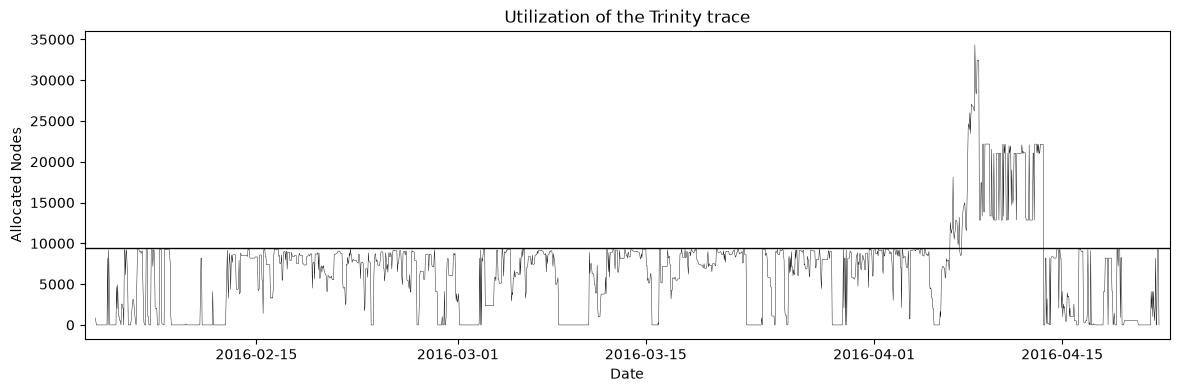

In [45]:
def node_series(arrive, depart, nodes, freq="1h"):
    """Nodes in use over time: +nodes at arrival, -nodes at departure,
    cumulative sum resampled to fixed bins."""
    events = pd.concat(
        [
            pd.Series(nodes.to_numpy(), index=arrive.to_numpy()),
            pd.Series(-nodes.to_numpy(), index=depart.to_numpy()),
        ]
    ).sort_index()
    return events.cumsum().resample(freq).last().ffill()


allocated = node_series(ran["start_time"], ran["end_time"], ran["node_count"])

print(f"allocation peak: {allocated.max():.0f} nodes at {allocated.idxmax()}")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(allocated.index, allocated.to_numpy(), color="black", linewidth=0.3)
ax.axhline(NUM_NODES, color="black", linewidth=1)
ax.set_xlabel("Date")
ax.set_ylabel("Allocated Nodes")
ax.set_title("Utilization of the Trinity trace")
ax.margins(x=0.01)
plt.show()


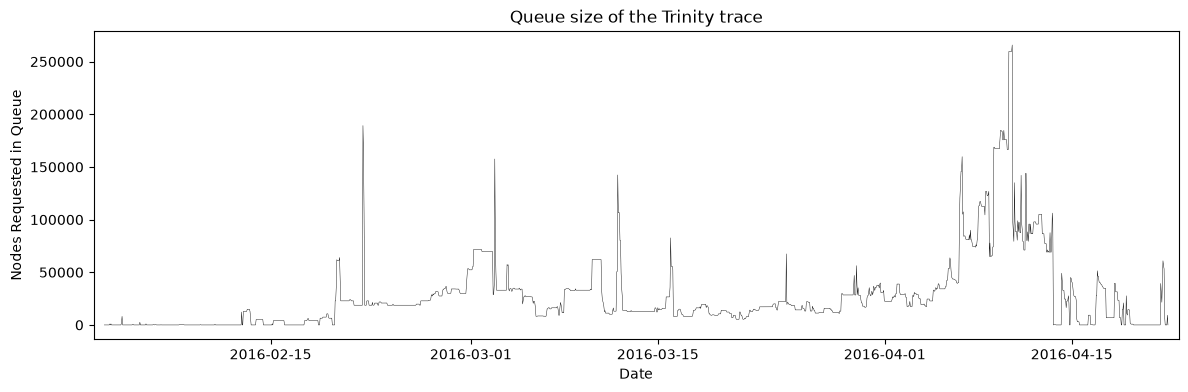

In [46]:
in_queue = node_series(queued["submit_time"], queued["depart_time"], queued["node_count"])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(in_queue.index, in_queue.to_numpy(), color="black", linewidth=0.3)
ax.set_xlabel("Date")
ax.set_ylabel("Nodes Requested in Queue")
ax.set_title("Queue size of the Trinity trace")
ax.margins(x=0.01)
plt.show()

## Selecting 4-week extracts for replay

Goal: pick 4-week windows to replay in Batsim for evaluating environmental-aware scheduling (carbon and water intensity signals) against FCFS and EASY backfilling baselines.

The selection criteria differ from the classic high-load replay recommendations. Since the heuristics work by shifting jobs in time or toggling backfilling, the windows must exercise both regimes. And since intensity signals vary on diurnal and weather timescales, a window must span multiple weeks, not hours.

Two windows are selected:

- **slack**: busy but not saturated. The friendly regime for time-shifting, the gentle one for backfill toggling.
- **stress**: heavily saturated. The regime where the FCFS vs EASY gap is widest and disabling backfilling has real consequences.

Search range: the whole trace, candidate windows anchored at Monday 00:00 UTC and slid by 1 week. The anchoring keeps the weekly phase identical across extracts and traces. The feasibility constraints below take care of excluding the pathological periods (ramp-up, drains, single-user bursts). Metrics per candidate window, all normalized by machine size so they transfer to other traces:

- `mean_util`, `std_util`: average and variability of node utilization.
- `frac_saturated`: fraction of hours at >= 95% capacity.
- `frac_low`: fraction of hours below 20% utilization.
- `max_low_streak_h`: longest contiguous run of low-utilization hours. Catches drain or maintenance events that a scattered-hours budget would let through.
- `mean_queue_norm`: average nodes requested in queue, in units of machine capacity.
- `jobs_submitted`, `top_user_share`: job-mix sanity. A window dominated by one user's burst makes results fragile.
- `wide_ns_share`: node-seconds share of wide jobs (>= 10% of the machine). Wide jobs create the reservations that make EASY differ from FCFS.
- `frac_bf_candidates`: share of narrow short jobs (<= 1% of the machine, <= 2 h), the jobs EASY can slip into reservation holes.

In [47]:
WINDOW = pd.Timedelta(weeks=4)
WIDE_NODES = 0.10 * NUM_NODES
BF_NODES = 0.01 * NUM_NODES
BF_RUNTIME_SEC = 2 * 3600

# Broad interval covering the April accounting artifact where summed node_count
# exceeds the documented Trinity capacity. Candidate replay windows overlapping
# this interval are excluded, while the full-trace diagnostic plot still shows it.
ANOMALOUS_INTERVALS = [
    (
        pd.Timestamp("2016-04-06 10:26:06-06:00"),
        pd.Timestamp("2016-04-13 09:23:05-06:00"),
    )
]


def overlaps_anomaly(start, end):
    return any(start < bad_end and end > bad_start for bad_start, bad_end in ANOMALOUS_INTERVALS)


def max_streak(mask):
    """Longest run of consecutive True values."""
    runs = mask.groupby((mask != mask.shift()).cumsum()).cumsum()
    return int(runs.max()) if len(runs) else 0


first_monday = (allocated.index[0].ceil("D") + pd.offsets.Week(weekday=0)).normalize()

rows = []
rejected_anomalous = []
for start in pd.date_range(first_monday, allocated.index[-1] - WINDOW, freq="W-MON"):
    end = start + WINDOW
    if overlaps_anomaly(start, end):
        rejected_anomalous.append(start)
        continue

    util = allocated[start:end] / NUM_NODES
    replayed = ran[(ran["submit_time"] >= start) & (ran["submit_time"] < end)]
    node_sec = replayed["node_count"] * replayed["runtime_sec"]
    wide = replayed["node_count"] >= WIDE_NODES
    bf = (replayed["node_count"] <= BF_NODES) & (replayed["runtime_sec"] <= BF_RUNTIME_SEC)
    submitted = queued[(queued["submit_time"] >= start) & (queued["submit_time"] < end)]
    rows.append(
        {
            "start": start,
            "mean_util": util.mean(),
            "std_util": util.std(),
            "frac_saturated": (util >= 0.95).mean(),
            "frac_low": (util < 0.2).mean(),
            "max_low_streak_h": max_streak(util < 0.2),
            "mean_queue_norm": in_queue[start:end].mean() / NUM_NODES,
            "jobs_submitted": len(replayed),
            "top_user_share": submitted["user_ID"].value_counts(normalize=True).iloc[0]
            if len(submitted)
            else 1.0,
            "wide_ns_share": node_sec[wide].sum() / node_sec.sum() if node_sec.sum() else 0.0,
            "frac_bf_candidates": bf.mean() if len(replayed) else 0.0,
        }
    )
windows = pd.DataFrame(rows).set_index("start")

print(f"candidate windows rejected for anomaly overlap: {len(rejected_anomalous)}")
for start in rejected_anomalous:
    print(f"  rejected {start.date()} -> {(start + WINDOW).date()}")
windows.round(3)


candidate windows rejected for anomaly overlap: 2
  rejected 2016-03-14 -> 2016-04-11
  rejected 2016-03-21 -> 2016-04-18


,mean_util,std_util,frac_saturated,frac_low,max_low_streak_h,mean_queue_norm,jobs_submitted,top_user_share,wide_ns_share,frac_bf_candidates
start,,,,,,,,,,
2016-02-08 00:00:00+00:00,0.588,0.373,0.123,0.242,53,2.033,4649,0.225,0.874,0.665
2016-02-15 00:00:00+00:00,0.634,0.348,0.146,0.183,55,2.749,3791,0.231,0.877,0.612
2016-02-22 00:00:00+00:00,0.626,0.357,0.180,0.201,55,2.807,3537,0.312,0.865,0.650
2016-02-29 00:00:00+00:00,0.617,0.375,0.214,0.230,55,2.594,4622,0.312,0.848,0.720
2016-03-07 00:00:00+00:00,0.671,0.364,0.260,0.204,55,2.252,4990,0.189,0.849,0.695


Feasibility constraints shared by both regimes:

- `top_user_share <= 0.5`: no single user dominates the job mix.
- `wide_ns_share >= 0.2` and `frac_bf_candidates >= 0.3`: enough wide jobs to force reservations and enough narrow short jobs to fill them, so EASY actually differs from FCFS.

For Trinity, `frac_low` and `max_low_streak_h` are diagnostics rather than hard constraints. The short OpenScience trace has long low-utilization stretches, and the April accounting artifact is handled explicitly by excluding overlapping candidate windows.

Regime-specific ranking:

- **slack**: prefer `0.5 <= mean_util <= 0.9` and `frac_saturated <= 0.3`. Ranked by `z(std_util) + z(mean_queue_norm)`: utilization variability indicates room to shift jobs, queue depth indicates sustained demand.
- **stress**: prefer `mean_util <= 0.95` and `0.3 < frac_saturated <= 0.5`. If no non-anomalous window reaches that saturation range, select the most pressured feasible non-anomalous window by `z(frac_saturated) + z(mean_queue_norm)`.


In [48]:
def zscore(s):
    if len(s) <= 1 or s.std() == 0:
        return s * 0
    return (s - s.mean()) / s.std()


common = (
    (windows["top_user_share"] <= 0.5)
    & (windows["wide_ns_share"] >= 0.2)
    & (windows["frac_bf_candidates"] >= 0.3)
)

slack = windows[
    common & windows["mean_util"].between(0.5, 0.9) & (windows["frac_saturated"] <= 0.3)
].copy()
if slack.empty:
    slack = windows[common].copy()
    print("No strict slack window found; falling back to all feasible non-anomalous Trinity windows.")
slack["score"] = zscore(slack["std_util"]) + zscore(slack["mean_queue_norm"])
slack = slack.sort_values("score", ascending=False)

stress = windows[
    common
    & (windows["mean_util"] <= 0.95)
    & (windows["frac_saturated"] > 0.3)
    & (windows["frac_saturated"] <= 0.5)
].copy()
if stress.empty:
    stress = windows[common & (windows["mean_util"] <= 0.95)].copy()
    print("No strict stress window found; using the most pressured feasible non-anomalous Trinity window.")
stress["score"] = zscore(stress["frac_saturated"]) + zscore(stress["mean_queue_norm"])
stress = stress.sort_values("score", ascending=False)

if slack.empty or stress.empty:
    raise ValueError("No feasible non-anomalous Trinity windows found with the current selection constraints.")

# Keep the extracts distinct when possible: stress gets the most pressured
# window, slack falls back to its next-ranked candidate if both rankings agree.
if slack.index[0] == stress.index[0] and len(slack) > 1:
    slack = slack.drop(index=stress.index[0])
    print("Slack and stress selected the same window; using the next slack candidate.")

EXTRACTS = {
    "slack": (slack.index[0], slack.index[0] + WINDOW),
    "stress": (stress.index[0], stress.index[0] + WINDOW),
}

for name, ranking in [("slack", slack), ("stress", stress)]:
    t0, t1 = EXTRACTS[name]
    print(f"{name}: {len(ranking)} feasible windows, selected {t0.date()} -> {t1.date()}")
pd.concat([slack.head(3), stress.head(3)], keys=["slack", "stress"]).round(3)


No strict stress window found; using the most pressured feasible non-anomalous Trinity window.
slack: 5 feasible windows, selected 2016-02-29 -> 2016-03-28
stress: 5 feasible windows, selected 2016-02-22 -> 2016-03-21


mean_util  std_util  frac_saturated  \
       start                                                            
slack  2016-02-29 00:00:00+00:00      0.617     0.375           0.214   
       2016-02-22 00:00:00+00:00      0.626     0.357           0.180   
       2016-02-08 00:00:00+00:00      0.588     0.373           0.123   
stress 2016-02-22 00:00:00+00:00      0.626     0.357           0.180   
       2016-02-29 00:00:00+00:00      0.617     0.375           0.214   
       2016-03-07 00:00:00+00:00      0.671     0.364           0.260   

                                  frac_low  max_low_streak_h  mean_queue_norm  \
       start                                                                    
slack  2016-02-29 00:00:00+00:00     0.230                55            2.594   
       2016-02-22 00:00:00+00:00     0.201                55            2.807   
       2016-02-08 00:00:00+00:00     0.242                53            2.033   
stress 2016-02-22 00:00:00+00:00     0.201                55            2.807   
       2016-02-29 00:00:00+00:00     0.230                55            2.594   
       2016-03-07 00:00:00+00:00     0.204                55            2.252   

                                  jobs_submitted  top_user_share  \
       start                                                       
slack  2016-02-29 00:00:00+00:00            4622           0.312   
       2016-02-22 00:00:00+00:00            3537           0.312   
       2016-02-08 00:00:00+00:00            4649           0.225   
stress 2016-02-22 00:00:00+00:00            3537           0.312   
       2016-02-29 00:00:00+00:00            4622           0.312   
       2016-03-07 00:00:00+00:00            4990           0.189   

                                  wide_ns_share  frac_bf_candidates  score  
       start                                                                
slack  2016-02-29 00:00:00+00:00          0.848               0.720  1.348  
       2016-02-22 00:00:00+00:00          0.865               0.650  0.409  
       2016-02-08 00:00:00+00:00          0.874               0.665 -0.494  
stress 2016-02-22 00:00:00+00:00          0.865               0.650  0.872  
       2016-02-29 00:00:00+00:00          0.848               0.720  0.863  
       2016-03-07 00:00:00+00:00          0.849               0.695  0.682

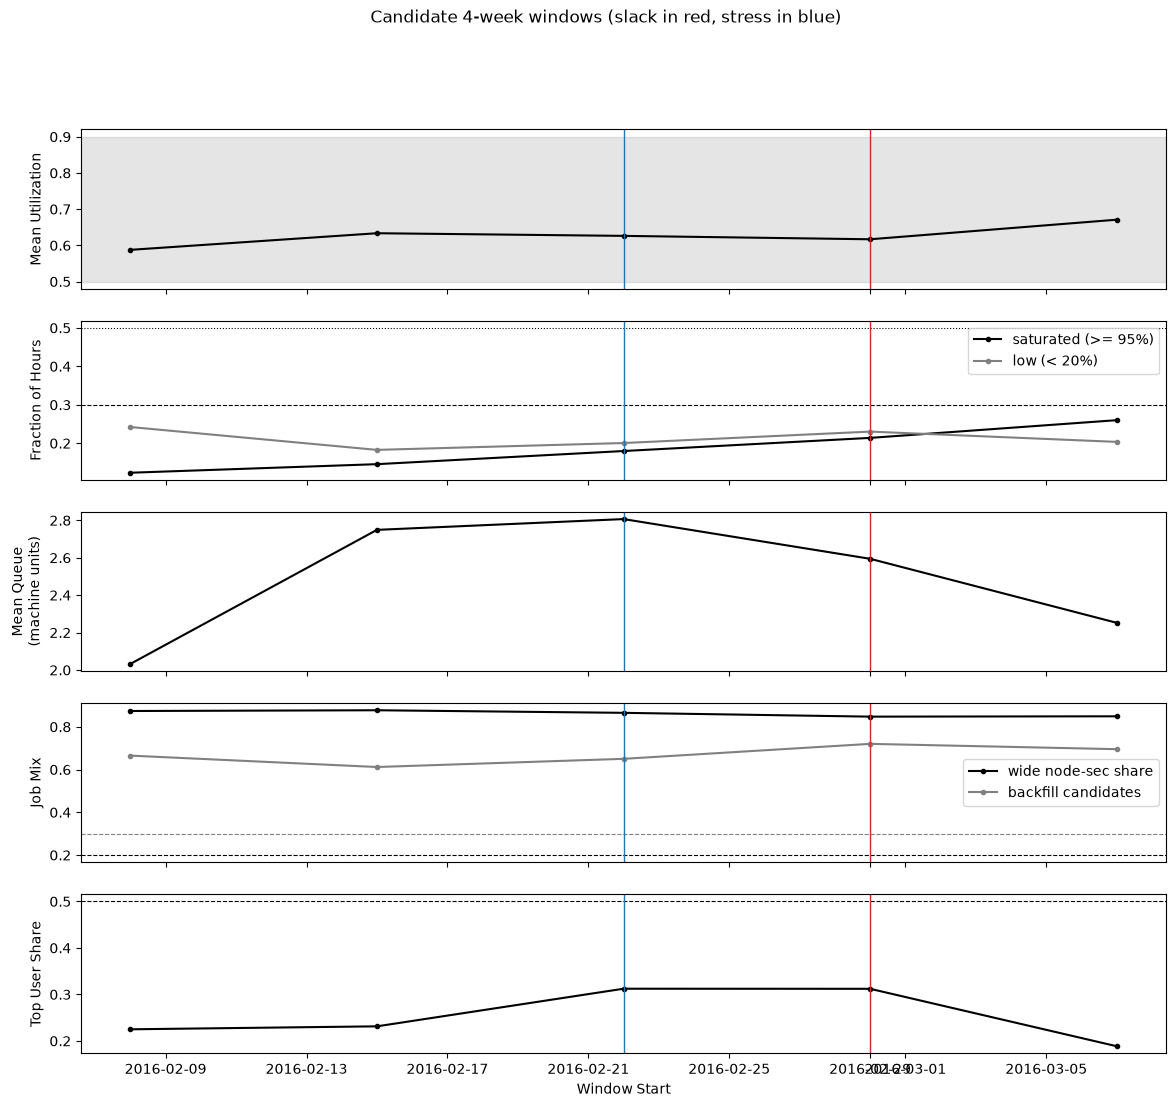

In [49]:
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)

axes[0].plot(windows.index, windows["mean_util"], marker=".", color="black")
axes[0].axhspan(0.5, 0.9, color="gray", alpha=0.2)
axes[0].set_ylabel("Mean Utilization")

axes[1].plot(windows.index, windows["frac_saturated"], marker=".", color="black", label="saturated (>= 95%)")
axes[1].plot(windows.index, windows["frac_low"], marker=".", color="gray", label="low (< 20%)")
axes[1].axhline(0.3, color="black", linewidth=0.8, linestyle="--")
axes[1].axhline(0.5, color="black", linewidth=0.8, linestyle=":")
axes[1].set_ylabel("Fraction of Hours")
axes[1].legend()

axes[2].plot(windows.index, windows["mean_queue_norm"], marker=".", color="black")
axes[2].set_ylabel("Mean Queue\n(machine units)")

axes[3].plot(windows.index, windows["wide_ns_share"], marker=".", color="black", label="wide node-sec share")
axes[3].plot(windows.index, windows["frac_bf_candidates"], marker=".", color="gray", label="backfill candidates")
axes[3].axhline(0.2, color="black", linewidth=0.8, linestyle="--")
axes[3].axhline(0.3, color="gray", linewidth=0.8, linestyle="--")
axes[3].set_ylabel("Job Mix")
axes[3].legend()

axes[4].plot(windows.index, windows["top_user_share"], marker=".", color="black")
axes[4].axhline(0.5, color="black", linewidth=0.8, linestyle="--")
axes[4].set_ylabel("Top User Share")
axes[4].set_xlabel("Window Start")

for ax in axes:
    ax.axvline(EXTRACTS["slack"][0], color="tab:red", linewidth=1)
    ax.axvline(EXTRACTS["stress"][0], color="tab:blue", linewidth=1)
fig.suptitle("Candidate 4-week windows (slack in red, stress in blue)")
plt.show()

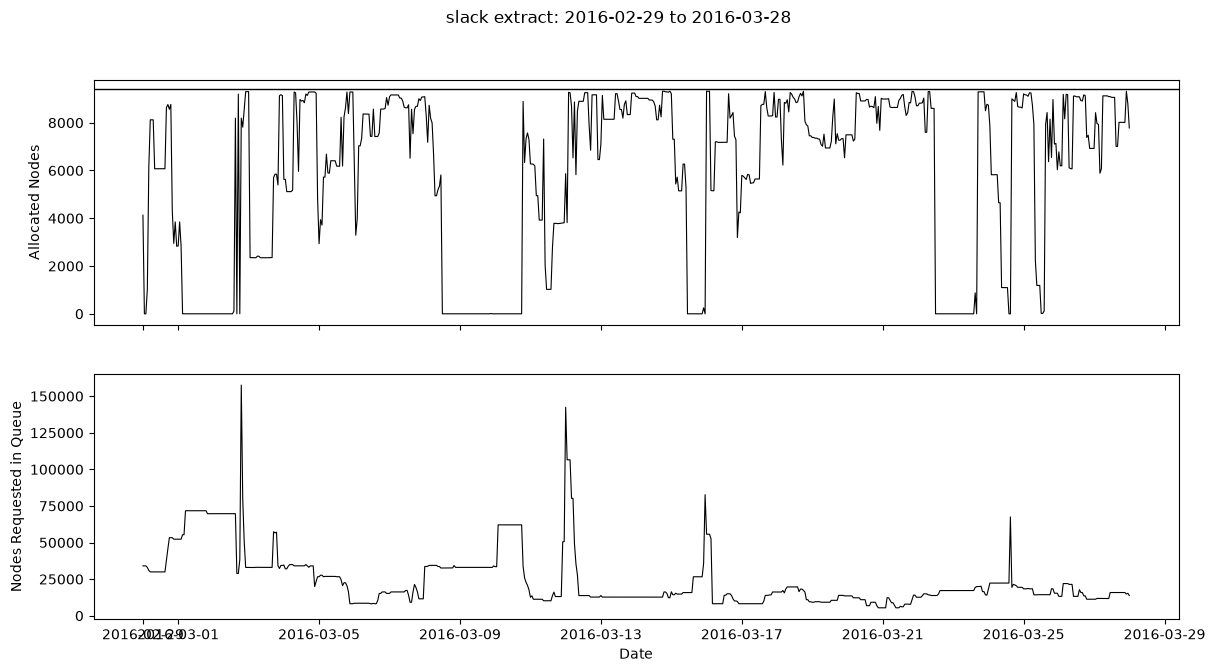

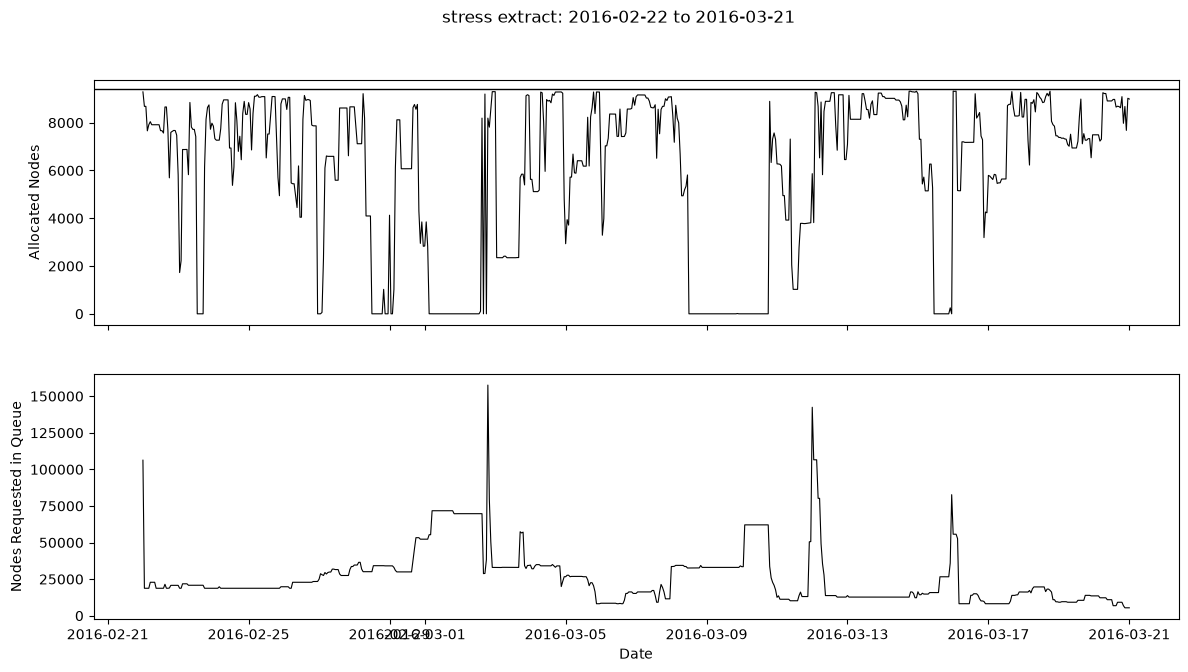

In [50]:
for name, (t0, t1) in EXTRACTS.items():
    fig, (ax_util, ax_queue) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    window_alloc = allocated[t0:t1]
    ax_util.plot(window_alloc.index, window_alloc.to_numpy(), color="black", linewidth=0.8)
    ax_util.axhline(NUM_NODES, color="black", linewidth=1)
    ax_util.set_ylabel("Allocated Nodes")

    window_queue = in_queue[t0:t1]
    ax_queue.plot(window_queue.index, window_queue.to_numpy(), color="black", linewidth=0.8)
    ax_queue.set_ylabel("Nodes Requested in Queue")
    ax_queue.set_xlabel("Date")

    fig.suptitle(f"{name} extract: {t0.date()} to {t1.date()}")
    plt.show()

## Batsim workload generation

One workload JSON per extract. Each job gets its own `parallel_homogeneous` profile with `cpu = runtime_sec * node_speed` and `com = 0` (network not modelled).

Jobs carry a walltime estimate because the EASY implementation (`easy_bf`) rejects jobs without one and builds its reservations from it. The estimate is the trace's `wallclock_limit` clipped so that `runtime <= walltime` always holds (walltime violations are not modelled, so TIMEOUT jobs that overran their limit in the real system get their walltime raised to the runtime).

> **Behavioral note**: because TIMEOUT jobs get `walltime = runtime` exactly, EASY's estimate for them is perfect, while every other job keeps its real, often loose, user estimate. This is the standard compromise when walltime violations are not modelled, but it slightly flatters backfilling accuracy for those jobs (about 7% of the trace).

Warm-up: the simulation starts with an empty machine, which the real system never was. To reproduce the system state at the extract start `T0`, all jobs that were in the system at `T0` are reset in the same state:

- **running at T0** (`start < T0 <= end`): submitted at `t = 0` with their *remaining* runtime and remaining walltime, ordered by original start time so FCFS reproduces the allocation order.
- **queued at T0** (`submit < T0 <= start`): submitted at `t = 0` with their full runtime, ordered by original submit time so they keep their queue positions. Jobs cancelled while queued are excluded since they have no defined runtime.

This defines two periods: the **warm-up** (environment setup at `t = 0`) and the **steady state**, which starts when the first replay job is submitted. Replay jobs are those submitted inside `[T0, T0 + 4 weeks)`, with `subtime` relative to `T0`. Evaluation metrics should be computed on the steady state only.

In [51]:
def job_entry(job_id, subtime, res, runtime_sec, walltime_sec, jobs, profiles):
    profiles[job_id] = {
        "type": "parallel_homogeneous",
        "cpu": float(runtime_sec) * node_speed,
        "com": 0.0,
    }
    jobs.append(
        {
            "id": job_id,
            "subtime": float(subtime),
            "res": int(res),
            "walltime": int(max(walltime_sec, np.ceil(runtime_sec))),
            "profile": job_id,
        }
    )


def build_workload(t0, t1):
    """Batsim workload for the extract [t0, t1): warm-up context jobs at t=0,
    then the replayed jobs with their original arrival offsets."""
    running = ran[(ran["start_time"] < t0) & (ran["end_time"] >= t0)]
    waiting = ran[(ran["submit_time"] < t0) & (ran["start_time"] >= t0)]
    replay = ran[(ran["submit_time"] >= t0) & (ran["submit_time"] < t1)]

    jobs, profiles = [], {}
    for i, row in enumerate(running.sort_values("start_time").itertuples(), start=1):
        elapsed = (t0 - row.start_time).total_seconds()
        remaining = max((row.end_time - t0).total_seconds(), 1.0)
        job_entry(
            f"ctx_run{i}", 0.0, row.node_count, remaining,
            row.walltime_sec - elapsed, jobs, profiles,
        )
    for i, row in enumerate(waiting.sort_values("submit_time").itertuples(), start=1):
        job_entry(
            f"ctx_queued{i}", 0.0, row.node_count, row.runtime_sec,
            row.walltime_sec, jobs, profiles,
        )
    for i, row in enumerate(replay.sort_values("submit_time").itertuples(), start=1):
        subtime = (row.submit_time - t0).total_seconds()
        job_entry(
            f"job{i}", subtime, row.node_count, row.runtime_sec,
            row.walltime_sec, jobs, profiles,
        )

    assert all(0 < j["res"] <= NUM_NODES for j in jobs), "Invalid job resource request."
    return {"nb_res": NUM_NODES, "jobs": jobs, "profiles": profiles}


for name, (t0, t1) in EXTRACTS.items():
    workload = build_workload(t0, t1)
    out_path = f"trinity_{name}.json"
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(workload, f, indent=2)

    by_kind = {"ctx_run": 0, "ctx_queued": 0, "job": 0}
    for job in workload["jobs"]:
        by_kind[job["id"].rstrip("0123456789")] += 1
    nodes_running_t0 = sum(
        j["res"] for j in workload["jobs"] if j["id"].startswith("ctx_run")
    )
    peak_job_res = max(j["res"] for j in workload["jobs"])
    steady_start = min(
        j["subtime"] for j in workload["jobs"] if j["id"].startswith("job")
    )
    print(
        f"{out_path}: {by_kind['ctx_run']} running + {by_kind['ctx_queued']} queued ctx jobs "
        f"({nodes_running_t0} nodes busy at t=0), {by_kind['job']} replay jobs, "
        f"largest job {peak_job_res} nodes, steady state from t={steady_start:.0f}s"
    )


trinity_slack.json: 0 running + 0 queued ctx jobs (0 nodes busy at t=0), 4622 replay jobs, largest job 9324 nodes, steady state from t=427s
trinity_stress.json: 34 running + 97 queued ctx jobs (8435 nodes busy at t=0), 3537 replay jobs, largest job 9324 nodes, steady state from t=2596s


## SimGrid platform generation

Homogeneous platform modelled after Trinity. Nodes are modelled at full-node granularity: no `core` attribute, each host computes at `node_speed` flops. Power states follow the SimGrid `wattage_per_state` format `idle:epsilon:all_cores`.


In [52]:
def create_prop(parent, prop_id, value):
    prop = ET.SubElement(parent, "prop")
    prop.set("id", prop_id)
    prop.set("value", value)


def generate_platform_xml(output_file, num_nodes=NUM_NODES):
    platform = ET.Element("platform")
    platform.set("version", "4.1")

    zone = ET.SubElement(platform, "zone")
    zone.set("id", ZONE_ID)
    zone.set("routing", "Full")

    # Management/login node, not a compute node. Batsim automatically assigns
    # the 'master' role to the master host.
    master = ET.SubElement(zone, "host")
    master.set("id", "master_host")
    create_prop(master, "role", "master")

    wattage = f"{IDLE_POWER_WATT}:{EPSILON_POWER_WATT}:{ALLCORES_POWER_WATT}"
    for i in range(num_nodes):
        node = ET.SubElement(zone, "host")
        node.set("id", f"node-{i}")
        node.set("speed", f"{node_speed / 1e9:g}Gf")
        create_prop(node, "role", "compute_node")
        create_prop(node, "wattage_per_state", wattage)

    tree = ET.ElementTree(platform)
    ET.indent(tree, space="    ")
    with open(output_file, "w") as f:
        f.write("<?xml version='1.0'?>\n")
        f.write('<!DOCTYPE platform SYSTEM "http://simgrid.gforge.inria.fr/simgrid/simgrid.dtd">\n')
        tree.write(f, encoding="unicode", xml_declaration=False)
    print(f"generated platform with {num_nodes} nodes at: {output_file}")


generate_platform_xml("trinity.xml")


generated platform with 9408 nodes at: trinity.xml


# References

[1] G. Amvrosiadis, J. W. Park, G. R. Ganger, G. A. Gibson, E. Baseman, and N. DeBardeleben, “On the diversity of cluster workloads and its impact on research results,” in 2018 USENIX annual technical conference (USENIX ATC 18), Boston, MA: USENIX Association, Jul. 2018, pp. 533–546. [Online]. Available: https://www.usenix.org/conference/atc18/presentation/amvrosiadis

[2] J. Emeras, “Workload Traces Analysis and Replay in Large Scale Distributed Systems,” Université Grenoble Alpes, 2013.

[3] E. Frachtenberg and D. G. Feitelson, “Pitfalls in parallel job scheduling evaluation,” in Job scheduling strategies for parallel processing, vol. 3834, D. Feitelson, E. Frachtenberg, L. Rudolph, and U. Schwiegelshohn, Eds., in Lecture Notes in Computer Science, vol. 3834. , Berlin, Heidelberg: Springer Berlin Heidelberg, 2005, pp. 257–282. doi: 10.1007/11605300_13.